In [ ]:
# ==========================================
# CONFIGURACIÓN GLOBAL
# ==========================================
import os

# 1. Diccionario de modelos: { 'Nombre': 'Ruta al archivo .pt' }
MODELS_PATHS = {
    'YOLOv8n': 'runs/models/yolov8n/weights/best.pt',
    'YOLOv8s': 'runs/models/yolov8s/weights/best.pt',
    'YOLO11n': 'runs/models/yolov11n/weights/best.pt',
    'YOLO11s': 'runs/models/yolov11s/weights/best.pt'
}

# 2. Ruta al dataset.yaml
DATA_YAML = '../data/dataset_mini/data.yaml'

# 3. Parámetros de validación
IMG_SIZE = 640
BATCH_SIZE = 16
DEVICE = 0

# 4. Carpeta de salida para este notebook
OUTPUT_DIR = 'comparativa_final'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
import pandas as pd
from ultralytics import YOLO
import torch

results_list = []

for name, path in MODELS_PATHS.items():
    print(f"--- Evaluando {name} ---")
    model = YOLO(path)

    # Ejecutar validación
    metrics = model.val(data=DATA_YAML, imgsz=IMG_SIZE, batch=BATCH_SIZE, device=DEVICE, plots=True, name=f"val_{name}")

    # Extraer Datos Operativos
    weight_mb = os.path.getsize(path) / (1024 * 1024)
    params_m = sum(p.numel() for p in model.model.parameters()) / 1e6

    # Extraer Métricas
    results_list.append({
        'Modelo': name,
        'mAP50-95': metrics.results_dict['metrics/mAP50-95(B)'],
        'mAP50': metrics.results_dict['metrics/mAP50(B)'],
        'Precisión': metrics.results_dict['metrics/precision(B)'],
        'Recall': metrics.results_dict['metrics/recall(B)'],
        'Inferencia (ms)': metrics.speed['inference'],
        'Parámetros (M)': params_m,
        'Peso (MB)': weight_mb,
        'Ruta_Plots': metrics.save_dir
    })

df_results = pd.DataFrame(results_list)
display(df_results)

--- Evaluando YOLOv8n ---
Ultralytics 8.4.37 🚀 Python-3.11.2 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1080, 8107MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.1 ms, read: 111.8±50.0 MB/s, size: 200.6 KB)
val: Scanning /home/jainogue/yolo/data/dataset_mini/valid/labels.cache... 200 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 7.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 4.8it/s 2.7s0.1s
                   all        200        342      0.931      0.819      0.896      0.501
                   Bee        104        256      0.903      0.796      0.874       0.51
          Asian Hornet         85         86       0.96      0.842      0.917      0.491
Speed: 1.4ms preprocess, 3.3ms inference, 0.0ms loss, 4.2ms postprocess per image
Results saved to /home/jainogue/yolo/notebooks/runs/detect/val_YOLOv8n4
--- Evaluan

,Modelo,mAP50-95,mAP50,Precisión,Recall,Inferencia (ms),Parámetros (M),Peso (MB),Ruta_Plots
0,YOLOv8n,0.500855,0.895654,0.931385,0.818991,3.264676,3.006038,5.963530,/home/jainogue/yolo/notebooks/runs/detect/val_...
1,YOLOv8s,0.531797,0.907621,0.927697,0.826853,7.146607,11.126358,21.481413,/home/jainogue/yolo/notebooks/runs/detect/val_...
2,YOLO11n,0.529470,0.910898,0.863475,0.848156,3.955520,2.582542,5.227797,/home/jainogue/yolo/notebooks/runs/detect/val_...
3,YOLO11s,0.536613,0.920928,0.920339,0.832211,7.488486,9.413574,18.295057,/home/jainogue/yolo/notebooks/runs/detect/val_...


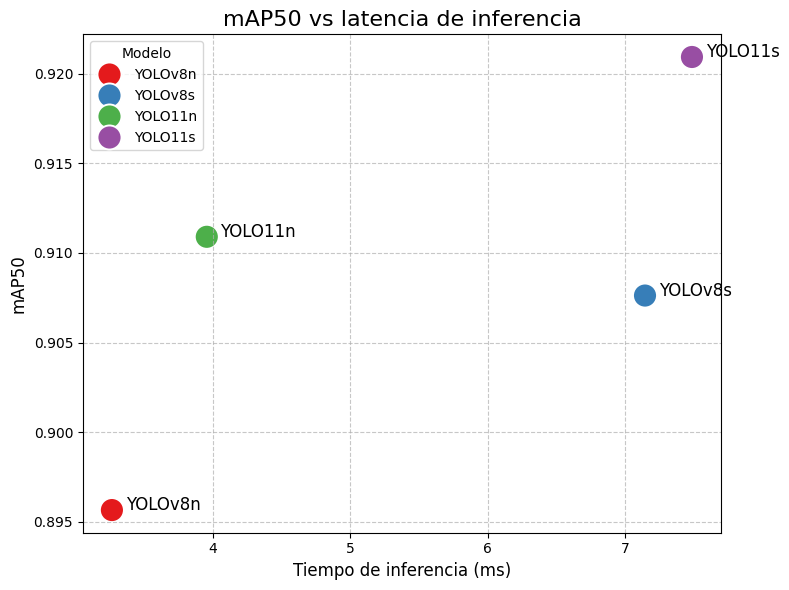

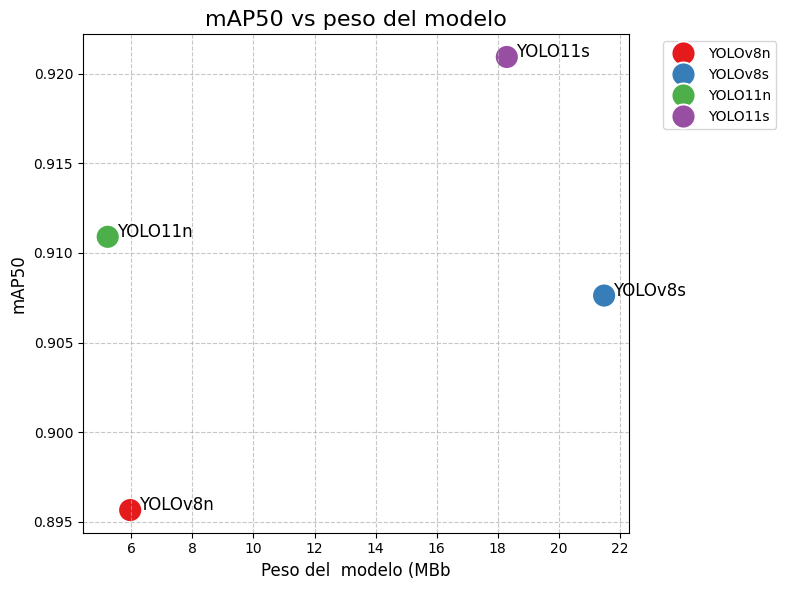

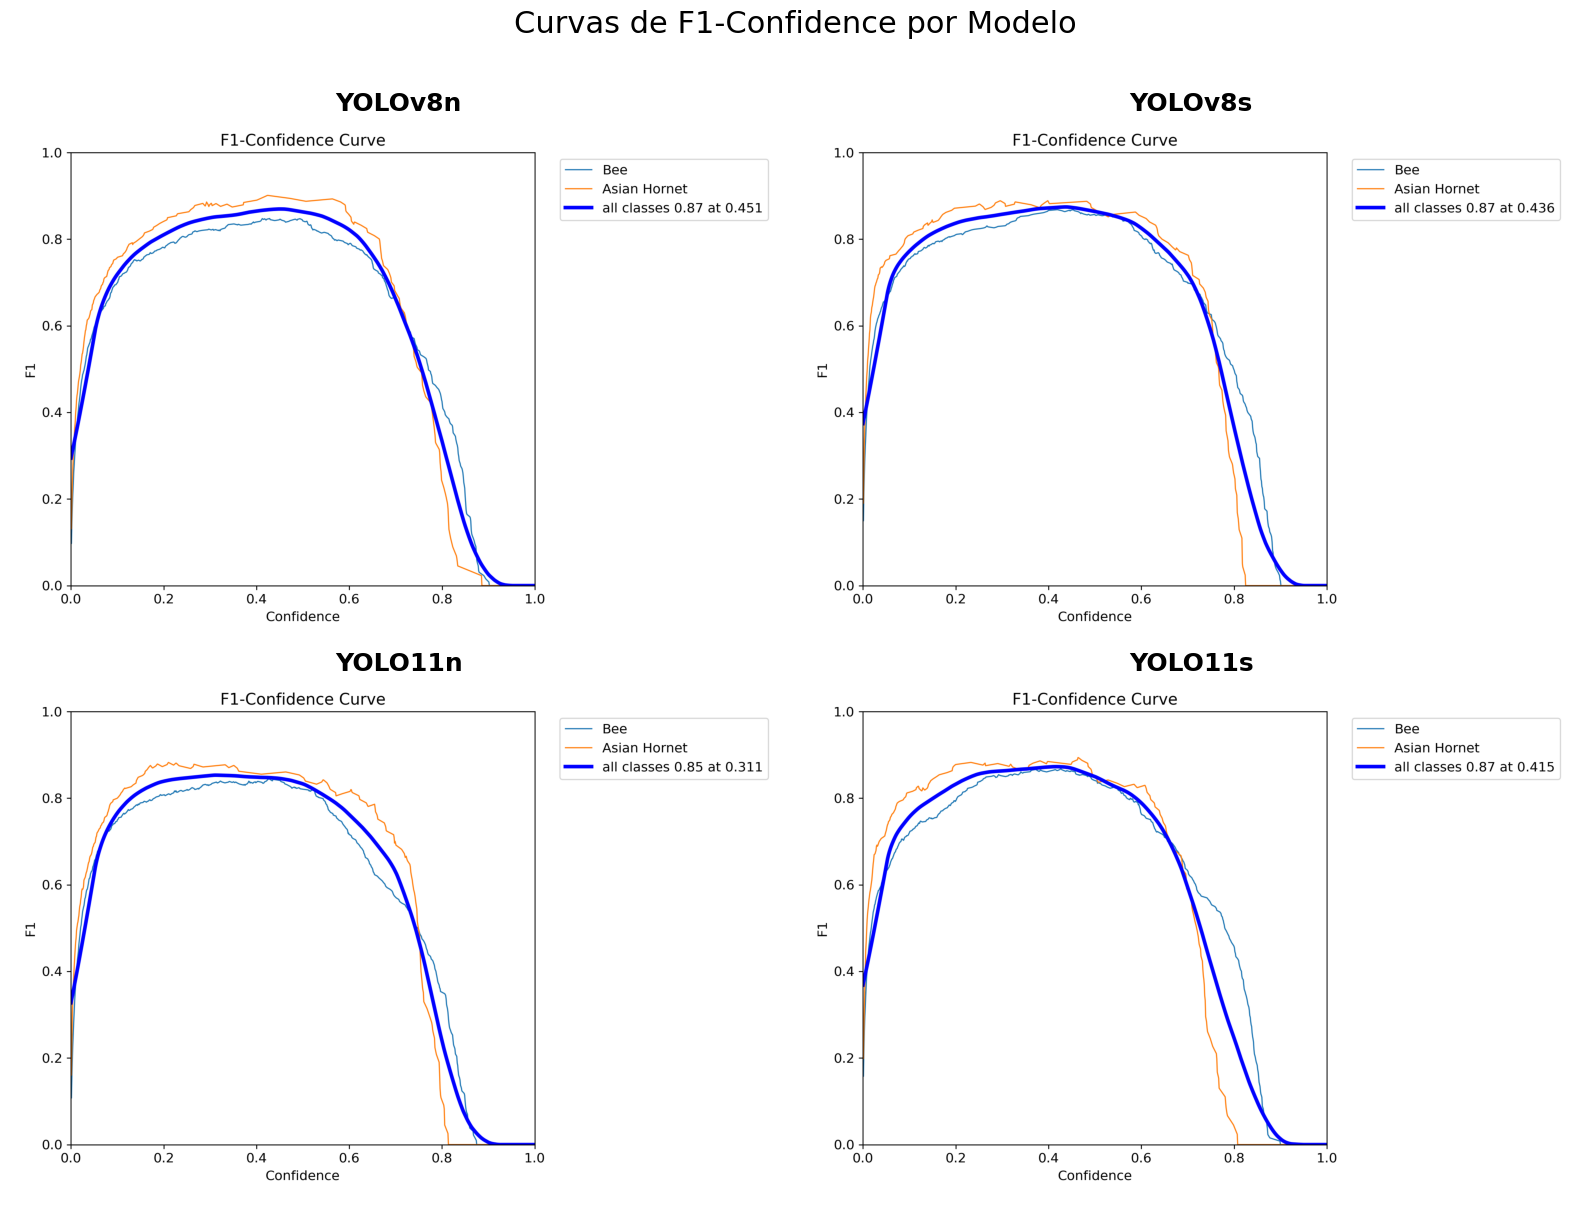

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
import os

# Calcular el F1-Score general para cada modelo
df_results['F1-Score'] = 2 * (df_results['Precisión'] * df_results['Recall']) / (df_results['Precisión'] + df_results['Recall'])

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_results, x='Inferencia (ms)', y='mAP50', hue='Modelo', s=300, palette='Set1')

for i, row in df_results.iterrows():
    plt.text(row['Inferencia (ms)'] + 0.1, row['mAP50'], row['Modelo'], fontsize=12)

plt.title('mAP50 vs latencia de inferencia', fontsize=16)
plt.xlabel('Tiempo de inferencia (ms)', fontsize=12)
plt.ylabel('mAP50', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

sns.scatterplot(data=df_results, x='Peso (MB)', y='mAP50', hue='Modelo', s=300, palette='Set1')

# Añadir las etiquetas de texto al lado de cada punto
for i, row in df_results.iterrows():
    plt.text(row['Peso (MB)'] + 0.3, row['mAP50'], row['Modelo'], fontsize=12)

plt.title('mAP50 vs peso del modelo', fontsize=16)
plt.xlabel('Peso del  modelo (MBb', fontsize=12)
plt.ylabel('mAP50', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('escalabilidad_parametros.png', dpi=300)
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
plt.suptitle('Curvas de F1-Confidence por Modelo', fontsize=22, y=1.02)

axs = axs.flatten()

for idx, row in df_results.iterrows():
    modelo_nombre = row['Modelo']
    ruta_plot = os.path.join(row['Ruta_Plots'], 'BoxF1_curve.png')

    if os.path.exists(ruta_plot):
        img = mpimg.imread(ruta_plot)
        axs[idx].imshow(img)
        axs[idx].axis('off')
        axs[idx].set_title(f'{modelo_nombre}', fontsize=18, fontweight='bold')
    else:
        axs[idx].text(0.5, 0.5, f'Imagen no encontrada\n{ruta_plot}', ha='center', va='center')
        axs[idx].axis('off')

plt.tight_layout()
plt.show()